In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score, classification_report, accuracy_score


# Load dataset asli (sesuaikan dengan lokasi file Anda)
df = pd.read_csv('Amazon Sale Report.csv', low_memory=False)

print("--- UKURAN DATASET ASLI ---")
print(f"Total baris: {df.shape[0]}")
print(f"Total kolom: {df.shape[1]}")
print("\n--- 5 BARIS PERTAMA DATA ---")
print(df.head())

--- UKURAN DATASET ASLI ---
Total baris: 128975
Total kolom: 24

--- 5 BARIS PERTAMA DATA ---
   index             Order ID      Date                        Status  \
0      0  405-8078784-5731545  04-30-22                     Cancelled   
1      1  171-9198151-1101146  04-30-22  Shipped - Delivered to Buyer   
2      2  404-0687676-7273146  04-30-22                       Shipped   
3      3  403-9615377-8133951  04-30-22                     Cancelled   
4      4  407-1069790-7240320  04-30-22                       Shipped   

  Fulfilment Sales Channel  ship-service-level    Style              SKU  \
0   Merchant      Amazon.in           Standard   SET389   SET389-KR-NP-S   
1   Merchant      Amazon.in           Standard  JNE3781  JNE3781-KR-XXXL   
2     Amazon      Amazon.in          Expedited  JNE3371    JNE3371-KR-XL   
3   Merchant      Amazon.in           Standard    J0341       J0341-DR-L   
4     Amazon      Amazon.in          Expedited  JNE3671  JNE3671-TU-XXXL   

        Ca

In [ ]:
print("=== MENGECEK DATA YANG HILANG (MISSING VALUES) ===")
print(df.isnull().sum())

# 1. Menghapus kolom yang tidak relevan atau hampir seluruhnya kosong
kolom_dihapus = ['Unnamed: 22', 'fulfilled-by', 'ship-country'] # ship-country dihapus karena semua nilainya 'IN' (India)
df.drop(columns=[col for col in kolom_dihapus if col in df.columns], inplace=True)

# 2. Mengubah tipe data Date menjadi Datetime agar bisa dianalisis berdasarkan waktu
df['Date'] = pd.to_datetime(df['Date'], format='%m-%d-%y', errors='coerce')

# 3. Imputasi Nilai 'Amount' yang kosong dengan Median berdasarkan Kategori Produk
# Ini menjaga agar nilai pengisian tetap objektif sesuai jenis barangnya
df['Amount'] = df.groupby('Category')['Amount'].transform(lambda x: x.fillna(x.median()))

print("\nPembersihan selesai! Jumlah data kosong pada 'Amount' sekarang:", df['Amount'].isnull().sum())

=== MENGECEK DATA YANG HILANG (MISSING VALUES) ===
index                     0
Order ID                  0
Date                      0
Status                    0
Fulfilment                0
Sales Channel             0
ship-service-level        0
Style                     0
SKU                       0
Category                  0
Size                      0
ASIN                      0
Courier Status         6872
Qty                       0
currency               7795
Amount                 7795
ship-city                33
ship-state               33
ship-postal-code         33
ship-country             33
promotion-ids         49153
B2B                       0
fulfilled-by          89698
Unnamed: 22           49050
dtype: int64

Pembersihan selesai! Jumlah data kosong pada 'Amount' sekarang: 0


In [ ]:
print("=== RINGKASAN STATISTIK DATA NUMERIK ===")
print(df[['Qty', 'Amount']].describe())

# Menghitung produk yang paling sering dibeli (Modus)
produk_terlaris = df['Category'].value_counts()
print("\n=== KATEGORI PRODUK PALING SERING DIBELI ===")
print(produk_terlaris)

# Menghitung persentase status pengiriman
status_logistik = df['Status'].value_counts(normalize=True) * 100
print("\n=== PROPORSI STATUS PESANAN (%) ===")
print(status_logistik.head())

=== RINGKASAN STATISTIK DATA NUMERIK ===
                 Qty         Amount
count  128975.000000  128975.000000
mean        0.904431     646.987324
std         0.313354     275.785274
min         0.000000       0.000000
25%         1.000000     437.140000
50%         1.000000     612.000000
75%         1.000000     788.000000
max        15.000000    5584.000000

=== KATEGORI PRODUK PALING SERING DIBELI ===
Category
Set              50284
kurta            49877
Western Dress    15500
Top              10622
Ethnic Dress      1159
Blouse             926
Bottom             440
Saree              164
Dupatta              3
Name: count, dtype: int64

=== PROPORSI STATUS PESANAN (%) ===
Status
Shipped                         60.324869
Shipped - Delivered to Buyer    22.305873
Cancelled                       14.213607
Shipped - Returned to Seller     1.514247
Shipped - Picked Up              0.754410
Name: proportion, dtype: float64


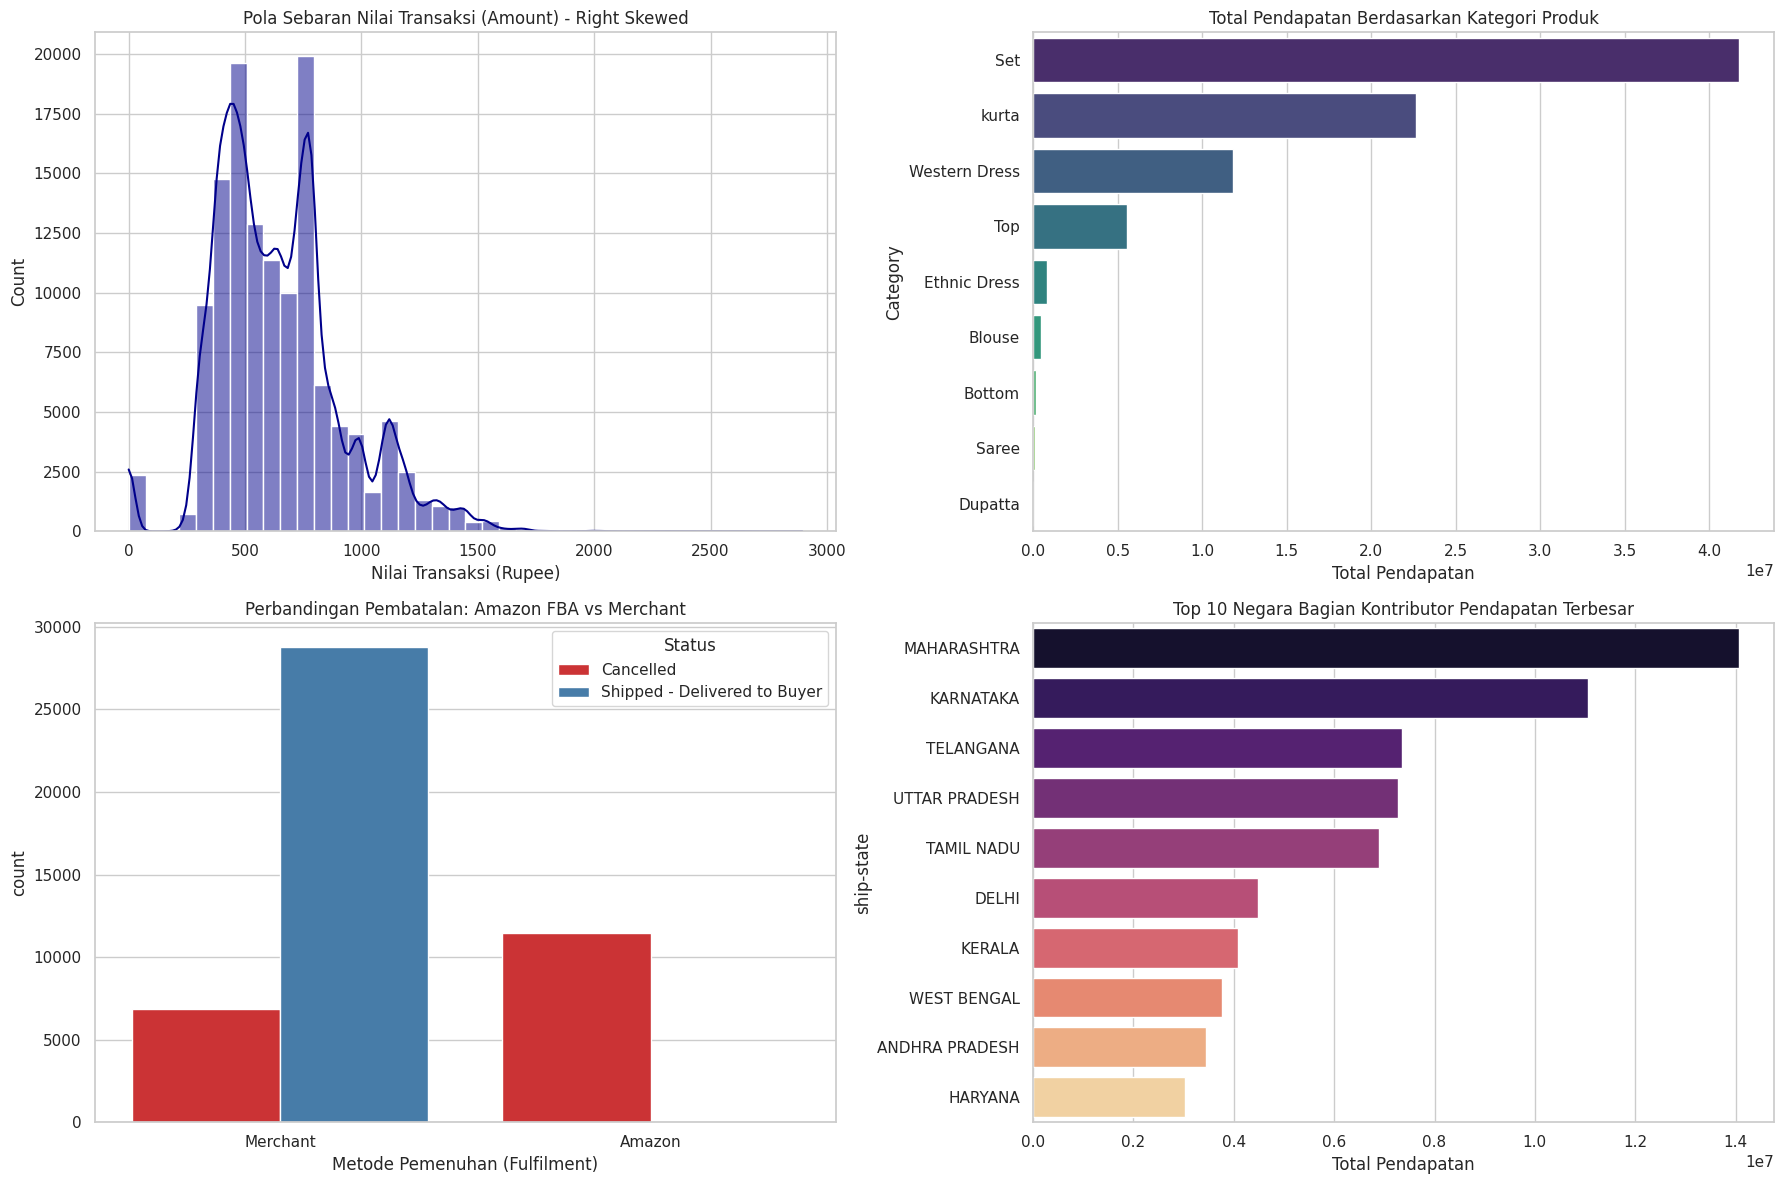

In [ ]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# 1. Distribusi Amount (Pola Sebaran Skewed)
# Membatasi nilai Amount < 3000 agar grafik utama terlihat jelas tanpa terganggu outlier ekstrem
sns.histplot(ax=axes[0,0], data=df[df['Amount'] < 3000], x='Amount', bins=40, kde=True, color='darkblue')
axes[0,0].set_title('Pola Sebaran Nilai Transaksi (Amount) - Right Skewed', fontsize=12)
axes[0,0].set_xlabel('Nilai Transaksi (Rupee)')

# 2. Bar Chart: Kategori Produk Kontributor Pendapatan Terbesar
category_revenue = df.groupby('Category')['Amount'].sum().sort_values(ascending=False).reset_index()
sns.barplot(ax=axes[0,1], data=category_revenue, x='Amount', y='Category', palette='viridis', hue='Category', legend=False)
axes[0,1].set_title('Total Pendapatan Berdasarkan Kategori Produk', fontsize=12)
axes[0,1].set_xlabel('Total Pendapatan')

# 3. Count Plot: Jenis Pemenuhan Logistik (Fulfilment) vs Status Pembatalan
# Kita persempit status menjadi 'Cancelled' dan 'Delivered' saja untuk simplisitas visual
df_filtered_status = df[df['Status'].isin(['Shipped - Delivered to Buyer', 'Cancelled'])]
sns.countplot(ax=axes[1,0], data=df_filtered_status, x='Fulfilment', hue='Status', palette='Set1')
axes[1,0].set_title('Perbandingan Pembatalan: Amazon FBA vs Merchant', fontsize=12)
axes[1,0].set_xlabel('Metode Pemenuhan (Fulfilment)')

# 4. Bar Chart: 10 Negara Bagian (State) dengan Penjualan Tertinggi
top_states = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10).reset_index()
sns.barplot(ax=axes[1,1], data=top_states, x='Amount', y='ship-state', palette='magma', hue='ship-state', legend=False)
axes[1,1].set_title('Top 10 Negara Bagian Kontributor Pendapatan Terbesar', fontsize=12)
axes[1,1].set_xlabel('Total Pendapatan')

plt.tight_layout()
plt.show()

## Conclusion from Exploratory Data Analysis

From the initial data loading, cleaning, and exploratory data analysis, we have observed several key insights:

*   **Dataset Size and Content**: The dataset contains 128,975 entries and 24 columns initially. After cleaning, irrelevant columns like 'Unnamed: 22', 'fulfilled-by', and 'ship-country' were removed, and the 'Date' column was correctly formatted.

*   **Missing Values**: Missing 'Amount' values were imputed using the median based on product categories, ensuring data integrity for numerical analysis.

*   **Numerical Statistics**: The average quantity (`Qty`) per order is around 0.9, and the average transaction amount (`Amount`) is approximately 647 Rupee.

*   **Top Categories**: 'Set' and 'kurta' are the most frequently purchased product categories, indicating their popularity among customers.

*   **Order Status**: A majority of orders are 'Shipped' (60.32%), followed by 'Shipped - Delivered to Buyer' (22.31%), and 'Cancelled' (14.21%).

*   **Amount Distribution**: The distribution of transaction amounts is right-skewed, suggesting that most transactions are for smaller values, with fewer high-value transactions.

*   **Revenue by Category**: 'Set' and 'kurta' not only lead in purchase frequency but also contribute the most to total revenue, solidifying their importance.

*   **Cancellation Comparison**: Orders fulfilled by 'Merchant' have a significantly higher number of cancellations compared to orders fulfilled by 'Amazon' (FBA), suggesting potential differences in service or operational efficiency.

*   **Top States by Revenue**: Maharashtra, Karnataka, and Telangana are the top three states contributing the most to total revenue, highlighting key geographical markets.